In [2]:
#Step 1: Load Dataset and Inspect
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
df = pd.read_csv('employees.csv')

print("First 5 Rows:\n", df.head())
print("\nInfo:\n")
print(df.info())

print("\nSummary:\n")
print(df.describe(include='all'))

First 5 Rows:
    EMPLOYEE_ID FIRST_NAME  LAST_NAME     EMAIL  PHONE_NUMBER  HIRE_DATE  \
0          198     Donald   OConnell  DOCONNEL  650.507.9833  21-JUN-07   
1          199    Douglas      Grant    DGRANT  650.507.9844  13-JAN-08   
2          200   Jennifer     Whalen       NaN  515.123.4444  17-SEP-03   
3          201    Michael  Hartstein  MHARTSTE  515.123.5555  17-FEB-04   
4          202        Pat        Fay      PFAY  603.123.6666  17-AUG-05   

     JOB_ID   SALARY COMMISSION_PCT MANAGER_ID  DEPARTMENT_ID  
0  SH_CLERK   2600.0             -         124             50  
1  SH_CLERK      NaN             -         124             50  
2   AD_ASST   4400.0             -         101             10  
3    MK_MAN  13000.0             -         100             20  
4    MK_REP   6000.0             -         201             20  

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dt


Missing Values Count:
 EMPLOYEE_ID        0
FIRST_NAME        10
LAST_NAME          0
EMAIL              6
PHONE_NUMBER       0
HIRE_DATE          0
JOB_ID             0
SALARY             5
COMMISSION_PCT     0
MANAGER_ID         0
DEPARTMENT_ID      0
dtype: int64

Missing %:
 EMPLOYEE_ID        0.000000
FIRST_NAME        18.181818
LAST_NAME          0.000000
EMAIL             10.909091
PHONE_NUMBER       0.000000
HIRE_DATE          0.000000
JOB_ID             0.000000
SALARY             9.090909
COMMISSION_PCT     0.000000
MANAGER_ID         0.000000
DEPARTMENT_ID      0.000000
dtype: float64


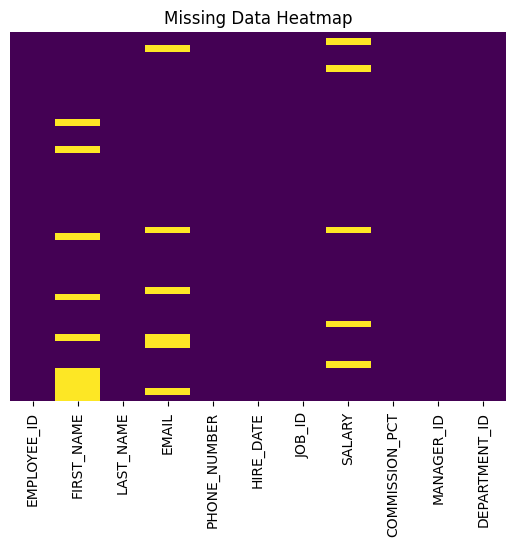

In [3]:
# step 2 : Check missing values count 
print("\nMissing Values Count:\n", df.isnull().sum())

missing_percentage = df.isnull().mean() * 100
print("\nMissing %:\n", missing_percentage)

# Heatmap
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

In [4]:
#op1
# Drop rows where SALARY is missing
df = df.dropna(subset=['SALARY'])

In [14]:

df['COMMISSION_PCT'] = df['COMMISSION_PCT'].replace(' - ', np.nan).infer_objects()
df['COMMISSION_PCT'] = pd.to_numeric(df['COMMISSION_PCT'], errors='coerce')

# Fill missing values
df['SALARY'] = df['SALARY'].fillna(df['SALARY'].mean())
df['COMMISSION_PCT'] = df['COMMISSION_PCT'].fillna(df['COMMISSION_PCT'].median())

# Optional
df['MANAGER_ID'] = df['MANAGER_ID'].fillna(df['MANAGER_ID'].mode()[0])
df['DEPARTMENT_ID'] = df['DEPARTMENT_ID'].fillna(df['DEPARTMENT_ID'].mode()[0])

In [6]:
#op3
# Fill categorical columns with mode
df['FIRST_NAME'] = df['FIRST_NAME'].fillna(df['FIRST_NAME'].mode()[0])
df['LAST_NAME'] = df['LAST_NAME'].fillna(df['LAST_NAME'].mode()[0])
df['EMAIL'] = df['EMAIL'].fillna(df['EMAIL'].mode()[0])
df['PHONE_NUMBER'] = df['PHONE_NUMBER'].fillna(df['PHONE_NUMBER'].mode()[0])
df['JOB_ID'] = df['JOB_ID'].fillna(df['JOB_ID'].mode()[0])

In [7]:
#step 4: method 1
Q1 = df['SALARY'].quantile(0.25)
Q3 = df['SALARY'].quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
df_cleaned = df[~((df['SALARY'] < (Q1 - 1.5 * IQR)) |
                  (df['SALARY'] > (Q3 + 1.5 * IQR)))]


In [8]:
#method 2 z-scores
z_scores = np.abs(stats.zscore(df['SALARY']))

# Keep normal data only
df_no_outliers = df[(z_scores < 3)]

In [9]:
#Step 5: Handle Duplicates
# Count duplicates
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

Duplicate Rows: 0


In [10]:
#Step 6: Correct Data Inconsistencies
df['FIRST_NAME'] = df['FIRST_NAME'].str.lower().str.strip()
df['LAST_NAME'] = df['LAST_NAME'].str.lower().str.strip()
df['EMAIL'] = df['EMAIL'].str.lower().str.strip()
df['JOB_ID'] = df['JOB_ID'].str.lower().str.strip()

df['JOB_ID'] = df['JOB_ID'].replace({
    'it_prog': 'it_programmer',
    'hr_rep': 'hr_representative'
})

# Remove invalid phone numbers
df = df[df['PHONE_NUMBER'] != 'INVALID']

# Fix negative salary
df['SALARY'] = df['SALARY'].abs()

In [11]:
print(df.head())
df.to_csv("emp1.csv")
print("file save")

   EMPLOYEE_ID FIRST_NAME  LAST_NAME     EMAIL  PHONE_NUMBER  HIRE_DATE  \
0          198     donald   oconnell  doconnel  650.507.9833  21-JUN-07   
2          200   jennifer     whalen    afripp  515.123.4444  17-SEP-03   
3          201    michael  hartstein  mhartste  515.123.5555  17-FEB-04   
4          202        pat        fay      pfay  603.123.6666  17-AUG-05   
6          204    hermann       baer     hbaer  515.123.8888  07-JUN-02   

     JOB_ID   SALARY  COMMISSION_PCT MANAGER_ID  DEPARTMENT_ID  
0  sh_clerk   2600.0             NaN        124             50  
2   ad_asst   4400.0             NaN        101             10  
3    mk_man  13000.0             NaN        100             20  
4    mk_rep   6000.0             NaN        201             20  
6    pr_rep  10000.0             NaN        101             70  
file save
